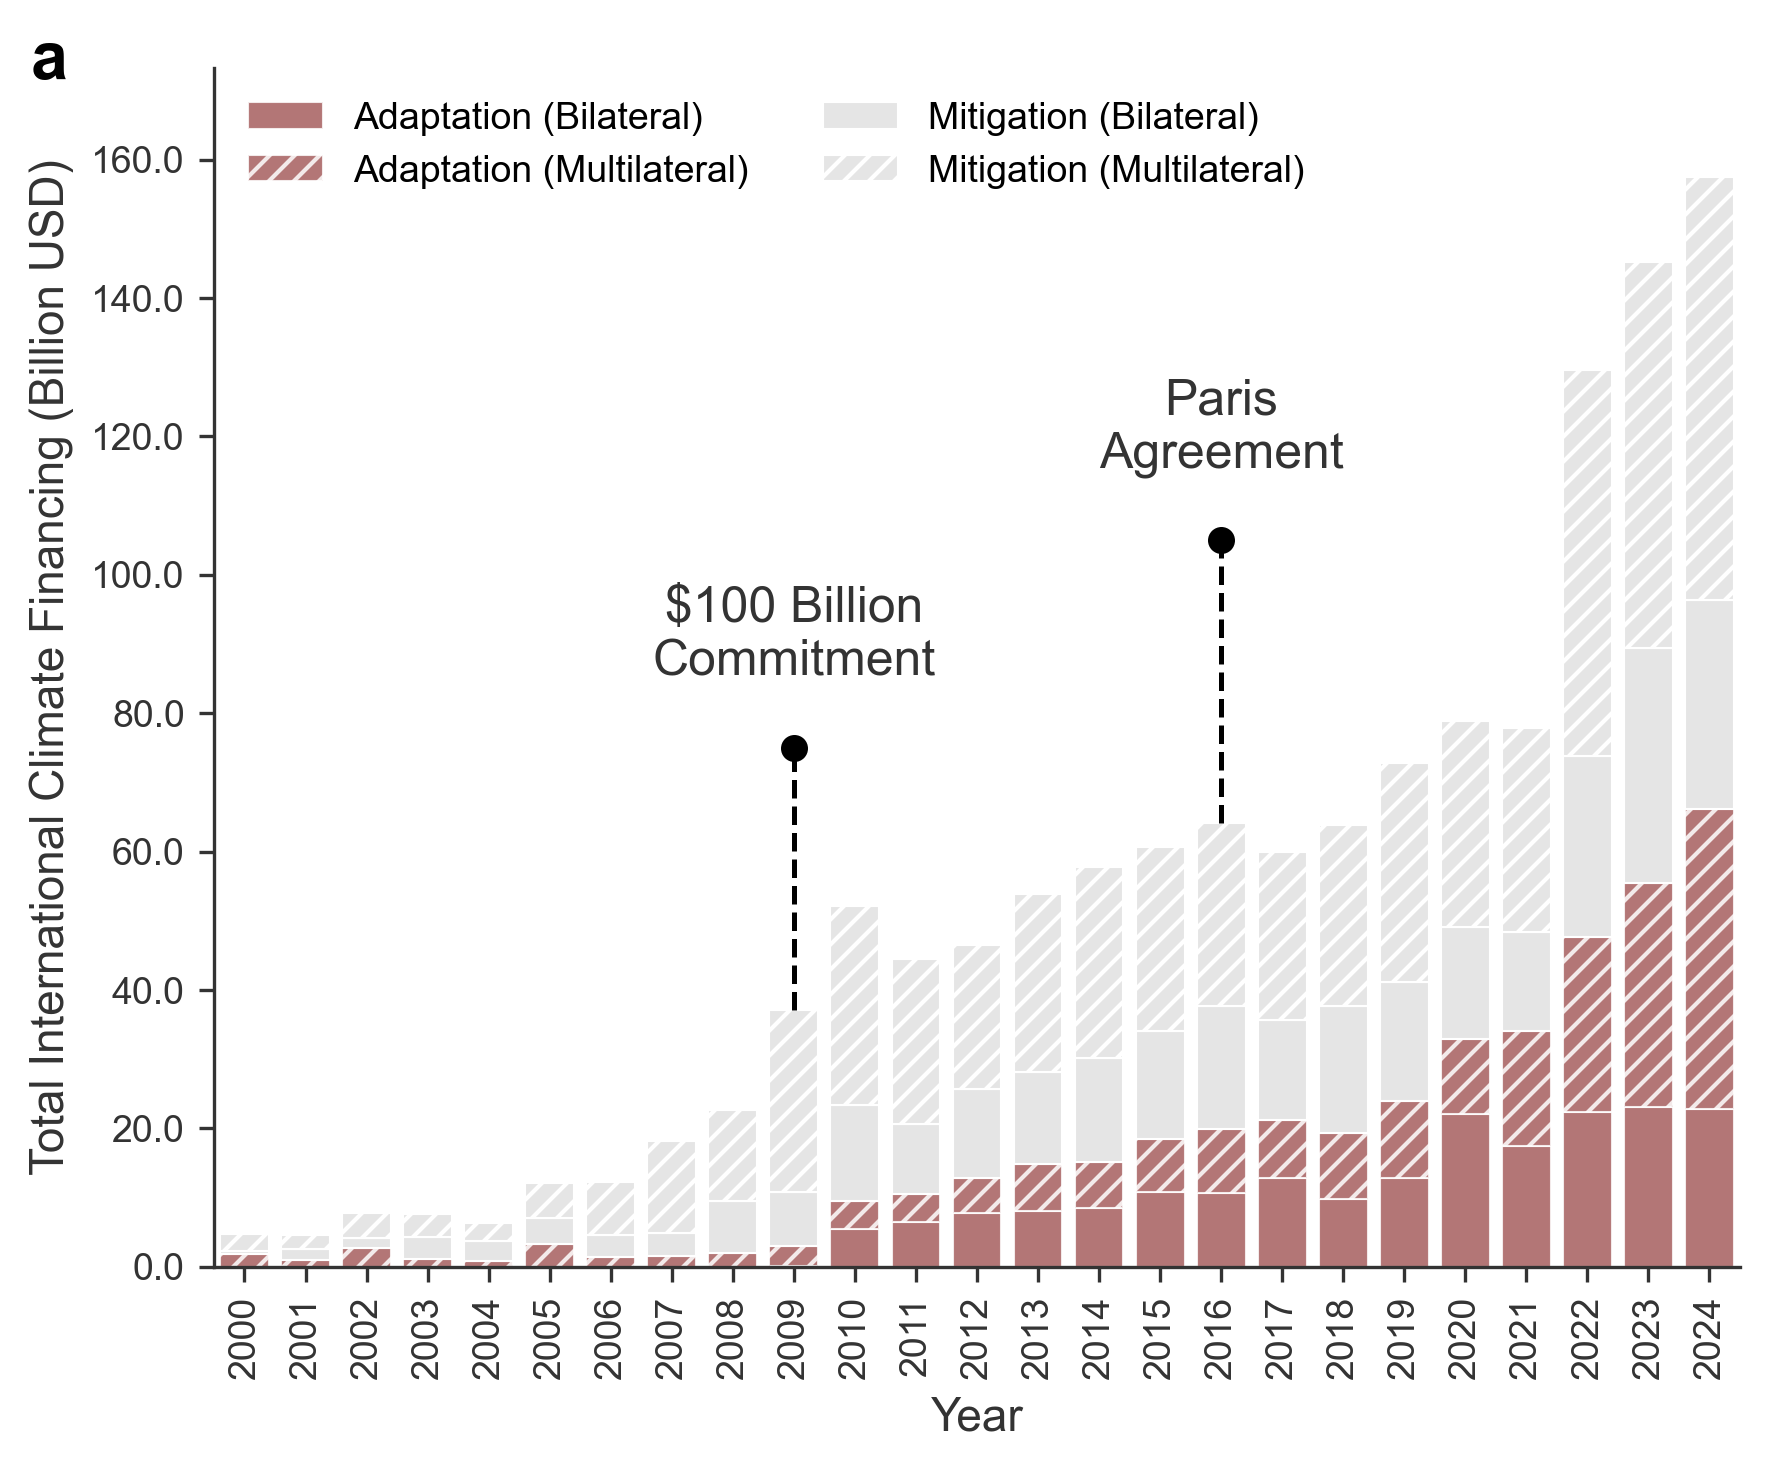

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# 1. 数据处理 (模拟数据，请在实际运行时替换回你的读取代码)
file_path = '../InputData/climatefinancedata/Climate_Finance_2000_2024.xlsx'
df = pd.read_excel(file_path)

# 筛选 2000 到 2024 年的数据
df_filtered = df[(df['Year'] >= 2000) & (df['Year'] <= 2024)]

# 按年份分组，提取需要的 4 列数据
df_yearly = df_filtered.groupby('Year')[['Bilateral_Adaptation', 
                                         'Multilateral_Adaptation',
                                         'Bilateral_Mitigation', 
                                         'Multilateral_Mitigation']].sum().reset_index()

# 2. 全局样式美化 - Nature 期刊风格设置
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica Neue', 'DejaVu Sans'], 
    'font.size': 10,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'axes.linewidth': 0.8
})

# --- 修改点: 核心强调与背景弱化 ---
adaptation_color = '#A65E5E'  # 深酒红/暗绯红 (保持深沉学术风，作为视觉焦点)

# 不再使用alpha透明度，而是直接使用特定的浅灰色系
mitigation_bg_color = '#E5E5E5'     # 减缓部分的浅灰色底色
mitigation_hatch_color = '#B0B0B0'  # 多边减缓部分的斜线颜色（稍深的灰），确保清晰度

marker_color = 'black'       # 标记点颜色
text_color = '#333333'       # 文本颜色

# 3. 开始绘制图表
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

# 提取数据
x = df_yearly['Year']
y1 = df_yearly['Bilateral_Adaptation']
y2 = df_yearly['Multilateral_Adaptation']
y3 = df_yearly['Bilateral_Mitigation']
y4 = df_yearly['Multilateral_Mitigation']

# 计算堆叠底色
total_adaptation = y1 + y2
total_heights = y1 + y2 + y3 + y4 

# --- 绘制堆叠柱状图 ---
# 强调 Adaptation：保持深沉颜色与高不透明度 (0.95)，边缘为白色
ax.bar(x, y1, color=adaptation_color, edgecolor='white', linewidth=0.5, label='Adaptation (Bilateral)', alpha=0.85)
ax.bar(x, y2, bottom=y1, color=adaptation_color, edgecolor='white', hatch='////', linewidth=0.5, label='Adaptation (Multilateral)', alpha=0.85)

# 弱化 Mitigation 但区分细节：
# 1. Bilateral 依然是纯色浅灰，边缘为白色
ax.bar(x, y3, bottom=total_adaptation, color=mitigation_bg_color, edgecolor='white', linewidth=0.5, label='Mitigation (Bilateral)')
# 2. Multilateral 浅灰底色，但把 edgecolor(决定斜线的颜色) 设置为稍深的灰色 (mitigation_hatch_color)
ax.bar(x, y4, bottom=total_adaptation+y3, color=mitigation_bg_color, edgecolor='white', hatch='////', linewidth=0.5, label='Mitigation (Multilateral)')

# 4. 图表格式美化
plt.xticks(x, rotation=90)
ax.set_xlabel('Year', color=text_color)

# 自动调整Y轴上限
ax.set_xlim(1999.5, 2024.5)
ax.set_ylim(0, total_heights.max() * 1.1)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
ax.set_ylabel('Total International Climate Financing (Billion USD)', color=text_color)

ax.grid(False)
ax.tick_params(axis='both', colors=text_color)
for spine in ax.spines.values():
    spine.set_color(text_color)

ax.text(-0.12, 0.98, 'a', transform=ax.transAxes, 
        fontsize=16, fontweight='bold', va='bottom', ha='left')

# 图例设置：两列并排，放在左上角
ax.legend(loc='upper left', frameon=False, ncol=2)

# 5. 添加关键节点标记 
x1 = 2009
y1_dot = 75.0 if 75.0 < ax.get_ylim()[1] else ax.get_ylim()[1] * 0.9 
if x1 in x.values:
    y1_top = total_heights[x == x1].values[0]
    plt.scatter(x1, y1_dot, s=30, color=marker_color, zorder=5)
    plt.vlines(x1, y1_top, y1_dot, colors=marker_color, linestyles='--', linewidth=1.2)
    plt.annotate('$100 Billion\nCommitment', xy=(x1, y1_dot), xytext=(0, 15), 
                 textcoords='offset points', ha='center', va='bottom', 
                 fontsize=12, linespacing=1.2, color=text_color)

x2 = 2016
y2_dot = 105.0 if 105.0 < ax.get_ylim()[1] else ax.get_ylim()[1] * 0.95 
if x2 in x.values:
    y2_top = total_heights[x == x2].values[0]
    plt.scatter(x2, y2_dot, s=30, color=marker_color, zorder=5)
    plt.vlines(x2, y2_top, y2_dot, colors=marker_color, linestyles='--', linewidth=1.2)
    plt.annotate('Paris\nAgreement', xy=(x2, y2_dot), xytext=(0, 15), 
                 textcoords='offset points', ha='center', va='bottom', 
                 fontsize=12, linespacing=1.2, color=text_color)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 自动调整布局防遮挡
plt.tight_layout()

# 6. 显示图表
plt.savefig('Final/Fig.1_Climate_Finance_Chart_Nature_GreyMitigation.png', bbox_inches='tight', dpi=900)
plt.show()